In [1]:
import numpy as np  
import pandas as pd  
from pandas_datareader import data as wb  
import matplotlib.pyplot as plt  
from scipy.stats import norm
%matplotlib inline

In [2]:
data = pd.read_csv('PG_2007_2017.csv', index_col = 'Date')

log_returns = np.log(1 + data.pct_change())

In [3]:
log_returns.tail()

,PG
Date,
2017-04-04,0.002562
2017-04-05,0.000667
2017-04-06,-0.006356
2017-04-07,-0.001903
2017-04-10,0.002910


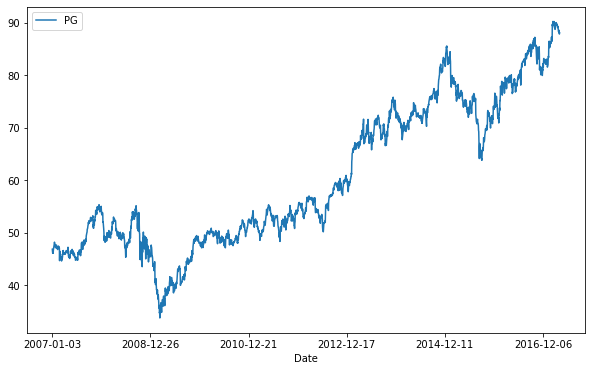

In [4]:
data.plot(figsize=(10, 6));

<AxesSubplot:xlabel='Date'>

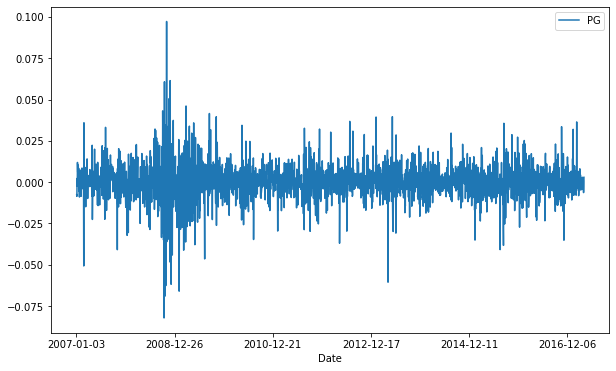

In [5]:
log_returns.plot(figsize = (10, 6))

In [6]:
u = log_returns.mean()
u

PG    0.000244
dtype: float64

In [7]:
var = log_returns.var()
var

PG    0.000124
dtype: float64

In [8]:
drift = u - (0.5 * var)
drift

PG    0.000182
dtype: float64

In [9]:
stdev = log_returns.std()
stdev

PG    0.011138
dtype: float64

******

In [10]:
type(drift)

pandas.core.series.Series

In [11]:
type(stdev)

pandas.core.series.Series

In [12]:
np.array(drift)

array([0.00018236])

In [13]:
drift.values

array([0.00018236])

In [14]:
stdev.values

array([0.0111381])

In [15]:
norm.ppf(0.95)

1.6448536269514722

In [16]:
x = np.random.rand(10, 2)
x

array([[0.63081044, 0.03924006],
       [0.14480283, 0.38861795],
       [0.1370625 , 0.65737319],
       [0.27816966, 0.50275023],
       [0.92651669, 0.3388486 ],
       [0.92282134, 0.46457564],
       [0.07772431, 0.90309453],
       [0.56306046, 0.51460711],
       [0.12732096, 0.43430636],
       [0.30905112, 0.86503412]])

In [18]:
norm.ppf(x)

array([[ 0.33400059, -1.75957369],
       [-1.05898707, -0.28292294],
       [-1.09361243,  0.4053046 ],
       [-0.58828751,  0.00689386],
       [ 1.45032966, -0.41560754],
       [ 1.42430806, -0.08891272],
       [-1.42054654,  1.2993876 ],
       [ 0.1587332 ,  0.03662277],
       [-1.13914684, -0.16542089],
       [-0.49854177,  1.10321972]])

In [19]:
Z = norm.ppf(np.random.rand(10,2))
Z

array([[ 0.42447167,  0.37964698],
       [-0.6480632 , -0.45899666],
       [-0.30701479,  0.4272694 ],
       [-0.71431762, -0.94310809],
       [-0.39105029, -1.25075542],
       [ 0.84086737,  0.55701842],
       [ 1.25444041, -0.835462  ],
       [-0.18640668, -0.57149443],
       [ 0.0083943 ,  2.12831625],
       [ 0.10582845, -0.9682436 ]])

In [21]:
t_intervals = 1000
iterations = 10

daily_returns = np.exp(drift.values + stdev.values * norm.ppf(np.random.rand(t_intervals, iterations)))

In [22]:
daily_returns

array([[0.99783952, 1.00273759, 1.00315136, ..., 0.99537726, 0.98721824,
        1.01114655],
       [1.02110229, 1.00371888, 1.02056089, ..., 1.00955581, 0.99611322,
        0.99770908],
       [0.98157728, 0.99118063, 0.9887742 , ..., 0.97711528, 0.98865069,
        0.972647  ],
       ...,
       [1.00010434, 1.00994104, 1.00958131, ..., 0.98904561, 0.98370653,
        0.98828155],
       [0.98918714, 1.00578026, 0.98331063, ..., 1.01582266, 0.98855298,
        1.00810544],
       [1.01096186, 0.98038817, 1.00399536, ..., 0.99555962, 0.99465392,
        1.00875259]])

***

$$
S_t = S_0 \mathbin{\cdot} daily\_return_t
$$
<br />

$$
S_{t+1} = S_t \mathbin{\cdot} daily\_return_{t+1}
$$

<br /> 
$$...$$
<br />  

$$
S_{t+999} = S_{t+998} \mathbin{\cdot} daily\_return_{t+999}
$$



In [23]:
S0 = data.iloc[-1]
S0

PG    88.118629
Name: 2017-04-10, dtype: float64

In [24]:
price_list = np.zeros_like(daily_returns)

In [25]:
price_list

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [26]:
price_list[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [27]:
price_list[0] = S0
price_list

array([[88.118629, 88.118629, 88.118629, ..., 88.118629, 88.118629,
        88.118629],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       ...,
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ]])

In [28]:
for t in range(1, t_intervals):
    price_list[t] = price_list[t - 1] * daily_returns[t]

In [29]:
price_list

array([[ 88.118629  ,  88.118629  ,  88.118629  , ...,  88.118629  ,
         88.118629  ,  88.118629  ],
       [ 89.97813407,  88.44633173,  89.93042664, ...,  88.96067354,
         87.7761309 ,  87.91675666],
       [ 88.32049168,  87.6662908 ,  88.92088526, ...,  86.9248335 ,
         86.77993195,  85.51196969],
       ...,
       [265.21366063,  87.00482402,  86.59386594, ..., 141.84303871,
         42.78897889, 103.22604541],
       [262.34594216,  87.50773432,  85.14866894, ..., 144.08737329,
         42.29917276, 104.06273764],
       [265.22174059,  85.79154716,  85.48886889, ..., 143.44757013,
         42.07303786, 104.97355592]])

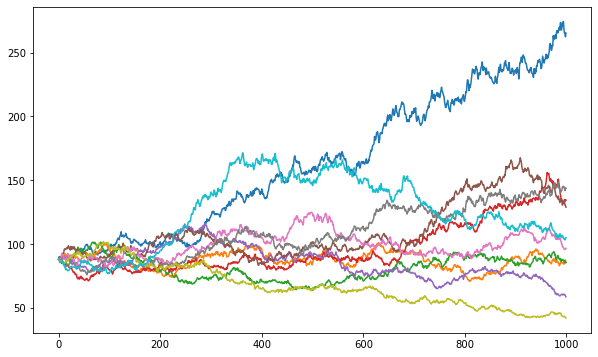

In [30]:
plt.figure(figsize=(10,6))
plt.plot(price_list);